In [32]:
import numpy as np

import bot
import state
import physics
import presets
import nn
import scoring
from constants import center_of_target_house, house_outer_circle_radius, STONE_RADIUS_M
import dataset


import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
def init_base_nn(
    *,
    num_stones_per_side: int,
    hidden_layer_size: int,
    output_layer_size: int,
    rng: np.random.Generator
):
    input_layer_size = 6 * 2 * num_stones_per_side
    l1 = nn.LinearBatched(
        rng.normal(size=(hidden_layer_size, input_layer_size))
        * np.sqrt(2 / input_layer_size)
    )
    act1 = nn.Max0()
    l2 = nn.LinearBatched(
        rng.normal(size=(hidden_layer_size, hidden_layer_size))
        * np.sqrt(2 / hidden_layer_size)
    )
    act2 = nn.Max0()
    l3 = nn.LinearBatched(
        rng.normal(size=(hidden_layer_size, hidden_layer_size))
        * np.sqrt(2 / hidden_layer_size)
    )
    act3 = nn.Max0()
    l4 = nn.LinearBatched(
        1
        / np.sqrt(hidden_layer_size)
        * rng.normal(size=(output_layer_size, hidden_layer_size))
    )
    layers = [l1, act1, l2, act2, l3, act3, l4]
    return nn.NN(layers)

## categorical score predictor

In [34]:
input_layer_size = 60
hidden_layer_size = 20
output_layer_size = 11

np.random.seed(42)

l1 = nn.LinearBatched(
    np.random.normal(size=(hidden_layer_size, input_layer_size))
    * np.sqrt(2 / input_layer_size)
)
act1 = nn.Max0()
l2 = nn.LinearBatched(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act2 = nn.Max0()
l3 = nn.LinearBatched(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act3 = nn.Max0()
l4 = nn.LinearBatched(
    1 / np.sqrt(hidden_layer_size) * np.random.normal(size=(output_layer_size, hidden_layer_size))
)
act4 = nn.MapTo01()

layers = [l1, act1, l2, act2, l3, act3, l4, act4]
neural_network = nn.NN(layers)

loss_function = nn.CrossEntropyLoss()

In [35]:
num_stones_per_side = 5
data = dataset.TrainingData.curling_random_sheet_states(
    num_sims=10_000, num_stones_per_side=num_stones_per_side
)

In [36]:
neural_network = init_base_nn(
    num_stones_per_side=num_stones_per_side,
    hidden_layer_size=20,
    output_layer_size=2*num_stones_per_side+1,
    rng=np.random.default_rng(42),
)

In [37]:
losses = []
num_points_per_batch = 100
num_iters = 200

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )

In [38]:
neural_network.run(data.input_features[:,:,None]).shape

(10000, 11, 1)

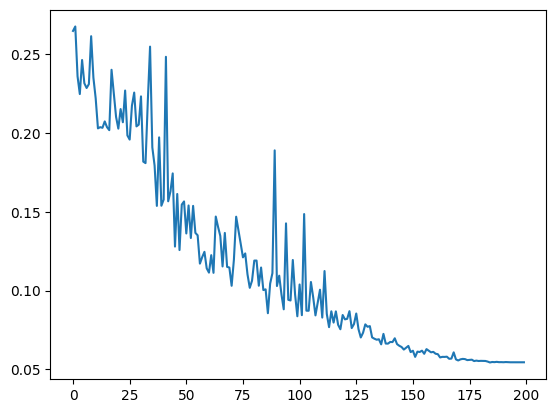

In [39]:
plt.plot(losses)

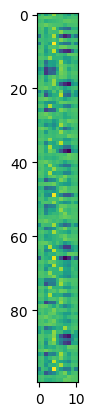

In [40]:
plt.imshow(neural_network.run(data.input_features[:, :, None])[:100,:,0])

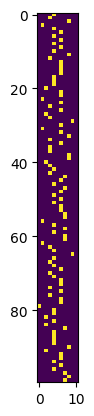

In [41]:
plt.imshow(data.answers[:100,:])

## predicting from second to last state

In [42]:
num_stones_per_side = 3

In [43]:
loss_function = nn.SquaredErrorLoss()

In [45]:
policy = bot.ArgmaxRandomThrowPolicy.max_single_turn_score(
    n_throws_per_state=100, random_action_prob=0.01
)

games = bot.run_games(
    num_sims=1_000,
    num_stones_per_side=3,
    first_player=policy,
    second_player=policy,
    seed=0,
)

In [46]:
first_player_scores = scoring.get_net_score_for_team(games[-1], 0)

In [47]:
data = dataset.TrainingData.curling(
    games[-2:],
    throws_remaining_by_team=[(0, 1), (0, 0)],
    final_scores=[first_player_scores]*2,
    seed=1,
    normalizer=None
)

In [48]:
losses = []
num_points_per_batch = 100
num_iters = 200

neural_network = init_base_nn(
    num_stones_per_side=num_stones_per_side,
    hidden_layer_size=20,
    output_layer_size=1,
    rng=np.random.default_rng(42),
)

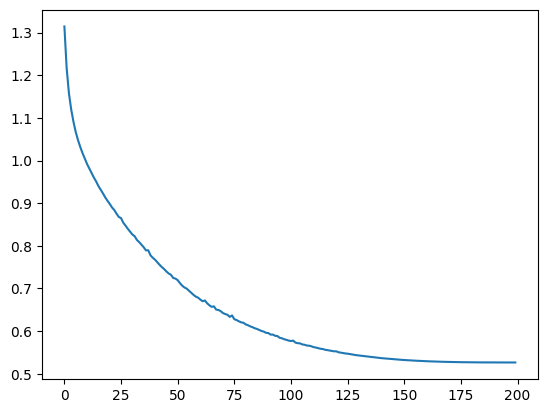

In [49]:
for i in range(num_iters):
    lr = .01 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )

plt.plot(losses)